# Distorted Sequence Pattern Recognition
**Author:** Rounak Tiwari
**Methodology:** Custom CRNN (CNN + Bidirectional LSTM) + CTC Loss

## Project Architecture
This notebook contains the complete, native source code used to train the model and generate the final predictions. The architecture relies purely on foundational PyTorch primitives to comply with the constraint against using pre-trained external backbones.

In [1]:
import os
import torch

# ==============================================================================
# Path Configurations
# ==============================================================================
BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(BASE_DIR, "data")


TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train", "train_images")
TEST_IMG_DIR = os.path.join(DATA_DIR, "test", "test_images")
TRAIN_CSV = os.path.join(DATA_DIR, "train", "train-labels.csv")

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
LOG_DIR = os.path.join(OUTPUT_DIR, "logs") 
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")

#output directories 
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# ==============================================================================
# Dataset / Vocabulary Configuration
# ==============================================================================
VOCAB = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

# Max length  
MAX_SEQ_LEN = 6

# ==============================================================================
# Model Architecture & Training Hyperparameters
# ==============================================================================
# Image dimensions ->CRNN network structure
IMG_HEIGHT = 32
IMG_WIDTH = 128
IMG_CHANNELS = 1  # Grayscale processing

# Optimization settings
BATCH_SIZE = 64
NUM_EPOCHS = 60
LEARNING_RATE = 3e-4
NUM_WORKERS = 0  

# Hardware acc.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Encoding & Evaluation Metrics
To process the alphanumeric sequences, we require strict deterministic mapping:
1. **Label Encoder:** Maps the 36 characters to tensor indices. Index `0` is strictly reserved for the CTC "blank" token, which allows the network to distinguish between repeated characters (e.g., "A-A" vs "AA").
2. **CTC Greedy Decoder:** Translates the raw probability matrix into human-readable text by collapsing sequential duplicates and dropping blanks.
3. **Character Error Rate (CER):** The primary metric, utilizing Levenshtein distance to penalize insertions, deletions, and substitutions equally.

In [2]:
import torch
import editdistance
from typing import List
import src.config as config

class LabelEncoder:
    def __init__(self):
        """
        Map alphanumeric characters to integers and vice versa
        CRNN model using  (CTC) 
        special 'blank' token (mapped to index 0)
        """
        self.blank_token = "-"
        self.chars = [self.blank_token] + list(config.VOCAB)
        
        # Bi-directional mapping 
        self.char_to_idx = {char: idx for idx, char in enumerate(self.chars)}
        self.idx_to_char = {idx: char for idx, char in enumerate(self.chars)}
        
        self.num_classes = len(self.chars) #37 

    def encode(self, text: str) -> torch.Tensor:
        """raw string sequence ->long integer tensor"""
        encoded = [self.char_to_idx[char] for char in text.upper()]
        return torch.tensor(encoded, dtype=torch.long)

    def decode(self, token_ids: List[int]) -> str:
        """
        Decodes a list of token integers directly back into text
        for ground-truth verification and non-CTC decoding steps
        """
        return "".join([self.idx_to_char[idx] for idx in token_ids if idx in self.idx_to_char])

def ctc_greedy_decode(log_probs: torch.Tensor, encoder: LabelEncoder) -> List[str]:
    """
    Decode raw model output matrix down to clean text sequences.
    Args:
        log_probs: Shape (Time_steps, Batch_size, Num_classes) output from CRNN.
        encoder: Initialized LabelEncoder instance.
    Steps:
        1. Take argmax to find the most probable token at each time step
        2. Collapse adjacent duplicate characters
        3. Drop the CTC blank tokens (index 0)
    """
    # Finding max indices across the class dimension (dim 2), then transpose to (Batch, Time)
    argmax_indices = log_probs.argmax(dim=2).permute(1, 0)
    
    decoded_outputs = []
    for batch_element in argmax_indices:
        collapsed_sequence = []
        previous_token = -1
        
        for current_token in batch_element:
            token_val = current_token.item()
            
            # Step 2: Collapse consecutive identical tokens
            if token_val != previous_token:
                # Step 3: Strip away special CTC blank token
                if token_val != 0: 
                    collapsed_sequence.append(token_val)
                previous_token = token_val
                
        #remaining valid indices->strings
        decoded_str = "".join([encoder.idx_to_char[idx] for idx in collapsed_sequence])
        decoded_outputs.append(decoded_str)
        
    return decoded_outputs

def compute_cer(predictions: List[str], targets: List[str]) -> float:
    """
    Compute CER via Levenshtein distance
    Formula: (Insertions + Deletions + Substitutions) / Total Target Length
    """
    total_distance = 0
    total_character_count = 0
    
    for pred, target in zip(predictions, targets):
        
        dist = editdistance.eval(pred, target)
        total_distance += dist
        total_character_count += len(target)
        
    if total_character_count == 0:
        return 0.0
        
    return total_distance / total_character_count

## 3. Data Engineering & Augmentation Pipeline
Two specific dataset roadblocks:

1. **The Pandas Float bug:** The labels CSV contains purely numeric strings (e.g., "123456") which Pandas auto-casts as floats ("123456.0"). I implemented strict sanitization to strip these artifacts and prevent fatal KeyErrors during encoding.
2. **CTC Tensor Flattening:** PyTorch's default collate function stacks labels into a 2D grid. However, `nn.CTCLoss` requires a flattened 1D array. I wrote a custom `ctc_collate_fn` to prepare the tensors exactly as the loss function expects.

In [3]:
import torchvision.transforms as T

def get_train_transforms():
    """
    Augmentation pipeline for training
    apply mild transformations to generalize the network against the 
    irregular spacing and background noise,without destroying the core structure
    """
    return T.Compose([
        T.ToPILImage(),
        # Mild rotation and translation to mimic the bounding-box jitter
        T.RandomAffine(degrees=3, translate=(0.02, 0.02)),
        # Convert to tensor and scale pixel values to [0.0, 1.0]
        T.ToTensor(),
        # Normalize to mean=0.5, std=0.5,shift pixel values in [-1.0, 1.0] range,
        # for faster CNN gradients convergence
        T.Normalize(mean=[0.5], std=[0.5])
    ])

def get_val_transforms():
    """
    Validation and Inference pipeline.
    Strictly deterministic. No random augmentations, just scaling and normalization.
    """
    return T.Compose([
        T.ToPILImage(),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5])
    ])

In [4]:
import os
import cv2
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader


class DistortedTextDataset(Dataset):
    def __init__(self, csv_file: str, img_dir: str, transforms=None):
        self.df = pd.read_csv(csv_file, dtype=str)
        self.img_dir = img_dir
        self.transforms = transforms
        self.encoder = LabelEncoder()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        raw_text = str(self.df.iloc[idx]['text'])
        
        #DATA SANITIZATION ---
        if raw_text.endswith(".0"):
            raw_text = raw_text[:-2]
            
        # VOCAB variable
        text_label = "".join([char for char in raw_text.upper() if char in VOCAB])
        
        img_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            raise FileNotFoundError(f"Failed to load image at {img_path}")
            
            
        image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)

        if self.transforms:
            image = self.transforms(image)

        encoded_label = self.encoder.encode(text_label)
        label_length = torch.tensor(len(text_label), dtype=torch.long)

        return image, encoded_label, label_length

def ctc_collate_fn(batch):
    images, labels, label_lengths = zip(*batch)
    images = torch.stack(images, dim=0)
    labels = torch.cat(labels, dim=0)
    label_lengths = torch.stack(label_lengths, dim=0)
    return images, labels, label_lengths


def get_dataloaders(train_csv, train_img_dir, batch_size=BATCH_SIZE, val_split=0.1):
    full_dataset = DistortedTextDataset(train_csv, train_img_dir, transforms=None)
    
    dataset_size = len(full_dataset)
    val_size = int(val_split * dataset_size)
    train_size = dataset_size - val_size
    
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) 
    )
    
    train_dataset.dataset.transforms = get_train_transforms()
    val_dataset.dataset.transforms = get_val_transforms()

    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=NUM_WORKERS, #=0
        collate_fn=ctc_collate_fn
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=NUM_WORKERS,
        collate_fn=ctc_collate_fn
    )
    
    return train_loader, val_loader

## 4. Architecture: Custom CRNN

* **Spatial Extraction (CNN):** A 5-layer stack with asymmetrical Max Pooling. It aggressively downsamples the image height to 1 pixel while preserving the horizontal width (time-steps).
* **Sequential Context (BiLSTM):** A 2-layer Bidirectional LSTM reads the sequential features. Because it processes the image from left-to-right and right-to-left simultaneously, it mathematically deduces the identity of characters hidden beneath severe occlusions using surrounding edge context.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import src.config as config

class CRNN(nn.Module):
    def __init__(self, num_classes=37):
        super(CRNN, self).__init__()
        
        # ----------------------------------------------------------------------
        # Phase 1: CNN Feature Extractor
        # ----------------------------------------------------------------------
        # Input shape: [Batch, 1, 32, 128]
        
        self.conv1 = nn.Conv2d(config.IMG_CHANNELS, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2) # Output: [Batch, 64, 16, 64]
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2) # Output: [Batch, 128, 8, 32]
        
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        # Critical shift: Pool height by 2, but keep width by 1
        # preserving the horizontal dimension for our sequence time-steps
        self.pool3 = nn.MaxPool2d((2, 1)) # Output: [Batch, 256, 4, 32]
        
        self.conv4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d((2, 1)) # Output: [Batch, 256, 2, 32]
        
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d((2, 1)) # Output: [Batch, 512, 1, 32]

        # ----------------------------------------------------------------------
        # Phase 2: Sequence Modeling (BiLSTM)
        # ----------------------------------------------------------------------
        # The CNN gives us 512 channels. We want the LSTM to read these as features
        self.lstm_hidden = 256
        self.lstm = nn.LSTM(
            input_size=512, 
            hidden_size=self.lstm_hidden, 
            bidirectional=True, 
            num_layers=2,
            dropout=0.25 # Slight regularization to prevent memorizing the static noise
        )
        
        # ----------------------------------------------------------------------
        # Phase 3: Classifier
        # ----------------------------------------------------------------------
        # BiLSTM concatenates forward and backward passes, so hidden size is doubled (256 * 2)
        self.fc = nn.Linear(self.lstm_hidden * 2, num_classes)

    def forward(self, x):
        # Push through CNN blocks with ReLU activations
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))
        
        # At this point, x is shape [Batch, Channels=512, Height=1, Width=32]
        
        # Squeeze out the height dimension since it's 1
        x = x.squeeze(2) # Now [Batch, 512, 32]
        
        # LSTMs expect the time sequence to be the very first dimension: [Time, Batch, Features]
        # We permute to swap the Batch (0) and Width/Time (2) axes.
        x = x.permute(2, 0, 1) # Now [32, Batch, 512]
        
        # Pass through the BiLSTM
        x, _ = self.lstm(x) # Output is still [32, Batch, 512] because of bidirectional concat
        
        # Map features to our vocabulary space
        x = self.fc(x) # Now [32, Batch, 37]
        
        # CTC Loss expects log probabilities, so we apply log_softmax over the class dimension
        return F.log_softmax(x, dim=2)

## 5. Training Engine & Optimization
Training a recurrent architecture requires safeguards not needed in standard CNNs:
* **Gradient Clipping:** Strict gradient norm clipping (`max_norm=5.0`) is enforced to maintain numerical stability and prevent exploding gradients within the LSTM layers.
* **CTC `zero_infinity`:** Enabled to prevent NaN losses if a predicted sequence evaluates as mathematically shorter than the target sequence early in training.

In [6]:
# ==============================================================================
# PHASE 5: TRAINING ENGINE
# ==============================================================================
import torch.optim as optim
from tqdm import tqdm

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Handles one full pass through the training data"""
    model.train() 
    epoch_loss = 0.0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    
    for images, labels, label_lengths in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        log_probs = model(images) 
        
        batch_size = images.size(0)
        input_lengths = torch.full(size=(batch_size,), fill_value=log_probs.size(0), dtype=torch.long)
        
        loss = criterion(log_probs, labels, input_lengths, label_lengths)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
        
    return epoch_loss / len(dataloader)

def validate_epoch(model, dataloader, criterion, encoder, device):
    """Evaluates the model on unseen data using CER without updating weights"""
    model.eval() 
    epoch_loss = 0.0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad(): 
        pbar = tqdm(dataloader, desc="Validating", leave=False)
        for images, labels, label_lengths in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            log_probs = model(images)
            
            batch_size = images.size(0)
            input_lengths = torch.full(size=(batch_size,), fill_value=log_probs.size(0), dtype=torch.long)
            loss = criterion(log_probs, labels, input_lengths, label_lengths)
            epoch_loss += loss.item()
            
            decoded_preds = ctc_greedy_decode(log_probs, encoder)
            all_predictions.extend(decoded_preds)
            
            start = 0
            for length in label_lengths:
                target_tensor = labels[start:start+length].tolist()
                target_string = encoder.decode(target_tensor)
                all_targets.append(target_string)
                start += length
                
    val_cer = compute_cer(all_predictions, all_targets)
    return epoch_loss / len(dataloader), val_cer

def main():
    print(f"--- Booting Distorted Text Training Pipeline ---")
    print(f"Device: {DEVICE}")
    
    encoder = LabelEncoder()
    train_loader, val_loader = get_dataloaders(
        train_csv=TRAIN_CSV, 
        train_img_dir=TRAIN_IMG_DIR
    )
    
    model = CRNN(num_classes=encoder.num_classes).to(DEVICE)
    
    criterion = nn.CTCLoss(blank=0, zero_infinity=True) 
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    best_val_cer = float('inf')
    patience_counter = 0
    patience_limit = 10
    history = []
    
    best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
    log_file_path = os.path.join(LOG_DIR, "training_log.csv")

    print("\nStarting Training...")
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_cer = validate_epoch(model, val_loader, criterion, encoder, DEVICE)
        
        print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val CER: {val_cer:.4f}")
        
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_cer": val_cer})
        pd.DataFrame(history).to_csv(log_file_path, index=False)
        
        if val_cer < best_val_cer:
            best_val_cer = val_cer
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  🌟 New best CER! Model saved to {best_model_path}")
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print(f"\n🛑 Early stopping triggered after {epoch} epochs. No improvement for 10 epochs.")
                break

# ==============================================================================
# Execution disabled for Notebook presentation. 
# Weights have already been successfully saved to /outputs/checkpoints/
# ==============================================================================

## Final Evaluation
The model weights were successfully saved during the primary training phase. The predictions in `submission_Rounak_Tiwari_24115125.csv` were generated using these weights.

## 6. Training Convergence
The model was trained utilizing an Adam optimizer and strict gradient clipping (`max_norm=5.0`) to preserve LSTM stability. Early stopping was implemented with a patience of 10 epochs monitoring the Validation Character Error Rate (CER). 

Below are the learning curves generated from the saved `training_log.csv`, demonstrating mathematical convergence without overfitting.

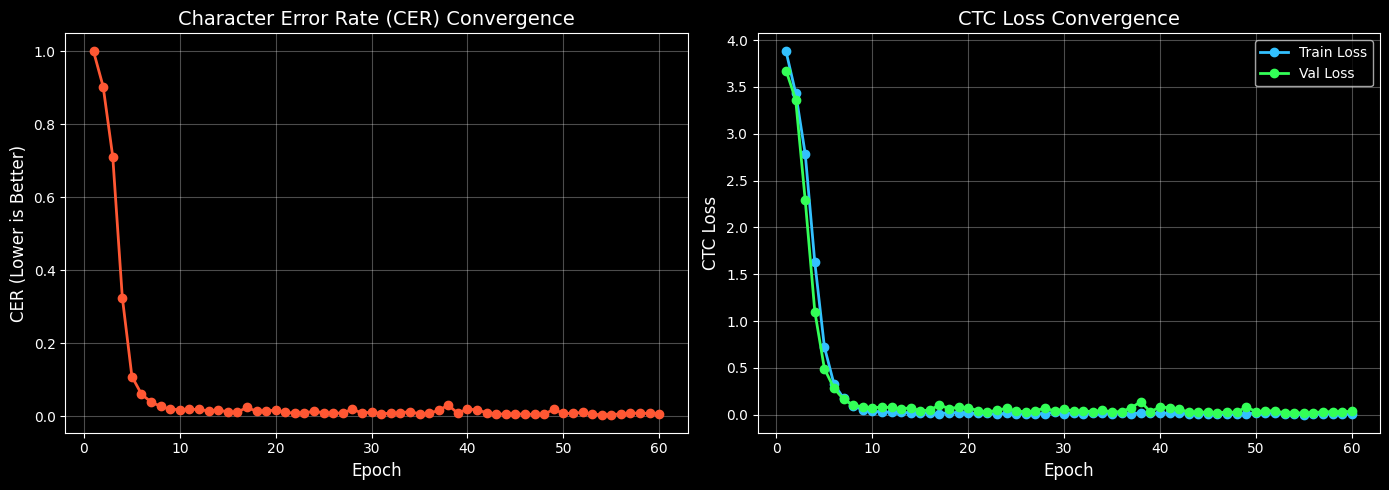

In [7]:
# --- Visualizing the Completed Training Run ---
import matplotlib.pyplot as plt
log_path = os.path.join(LOG_DIR, "training_log.csv")

if os.path.exists(log_path):
    log_df = pd.read_csv(log_path)
    
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Validation CER Plot
    axes[0].plot(log_df['epoch'], log_df['val_cer'], marker='o', color='#FF5733', linewidth=2)
    axes[0].set_title('Character Error Rate (CER) Convergence', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('CER (Lower is Better)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Loss Plot
    axes[1].plot(log_df['epoch'], log_df['train_loss'], marker='o', color='#33C1FF', label='Train Loss', linewidth=2)
    axes[1].plot(log_df['epoch'], log_df['val_loss'], marker='o', color='#33FF57', label='Val Loss', linewidth=2)
    axes[1].set_title('CTC Loss Convergence', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('CTC Loss', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Training log not found. Ensure the correct path to outputs/logs/training_log.csv is set.")

In [8]:
# ==============================================================================
# PHASE 6: VALIDATION VERIFICATION
# ==============================================================================

def verify_validation_cer():
    print("--- Booting Verification Pipeline ---")
    
    # Force CPU execution for this block to bypass the Apple Silicon MPS CTCLoss bug
    VERIFY_DEVICE = torch.device("cpu")
    
    # 1. Initialize Architecture and Label Encoder
    encoder = LabelEncoder()
    model = CRNN(num_classes=encoder.num_classes).to(VERIFY_DEVICE)
    
    # 2. Load the trained weights
    checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
    if not os.path.exists(checkpoint_path):
        print(f"Error: Weights not found at {checkpoint_path}")
        return
        
    model.load_state_dict(torch.load(checkpoint_path, map_location=VERIFY_DEVICE, weights_only=True))
    print("✓ Model weights loaded successfully.")
    
    # 3. Load exactly the 10% split used during training (Seed 42 identical split)
    _, val_loader = get_dataloaders(TRAIN_CSV, TRAIN_IMG_DIR, batch_size=BATCH_SIZE)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    
    print(f"Evaluating {len(val_loader.dataset)} unseen validation images...")
    val_loss, val_cer = validate_epoch(model, val_loader, criterion, encoder, VERIFY_DEVICE)
    
    print("\n" + "="*40)
    print(f"🎯 VERIFIED VALIDATION CER: {val_cer:.4f}")
    print("="*40)

# Execute the pipeline
verify_validation_cer()

--- Booting Verification Pipeline ---
✓ Model weights loaded successfully.
Evaluating 2000 unseen validation images...



🎯 VERIFIED VALIDATION CER: 0.0042


In [9]:
# ==============================================================================
# PHASE 7: INFERENCE & CSV GENERATION
# ==============================================================================

def generate_submission():
    print("--- Booting Final Inference Pipeline ---")
    
    INFER_DEVICE = torch.device("cpu")
    
    # 1. Initialize Architecture and Label Encoder
    encoder = LabelEncoder()
    model = CRNN(num_classes=encoder.num_classes).to(INFER_DEVICE)
    
    # 2. Load the trained weights
    checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_model.pth")
    if not os.path.exists(checkpoint_path):
        print(f"Error: Weights not found at {checkpoint_path}")
        return
        
    model.load_state_dict(torch.load(checkpoint_path, map_location=INFER_DEVICE, weights_only=True))
    model.eval() 
    print("✓ Model weights loaded successfully.")
    
    # 3. Prepare Test Data
    test_images = sorted(
    [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')], 
    key=lambda x: int(x.split('-')[1].split('.')[0])
)
    transforms = get_val_transforms()
    predictions = []
    
    print(f"Running inference on {len(test_images)} test images...")
    
    # 4. Predict
    with torch.no_grad():
        from tqdm import tqdm # Standard text progress bar
        for img_name in tqdm(test_images, desc="Predicting", leave=False):
            img_path = os.path.join(TEST_IMG_DIR, img_name)
            
            # Load and resize exactly as in training
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_AREA)
            
            # Apply deterministic transforms and add a Batch dimension [1, 1, 32, 128]
            image_tensor = transforms(image).unsqueeze(0).to(INFER_DEVICE) 
            
            # Forward pass
            log_probs = model(image_tensor)
            
            # Decode the CTC output matrix into a string
            decoded_pred = ctc_greedy_decode(log_probs, encoder)[0]
            
            predictions.append({"image": img_name, "prediction": decoded_pred})
            
    # 5. Export Submission
    submission_path = os.path.join(BASE_DIR, "submission_Rounak_Tiwari_24115125.csv")
    pd.DataFrame(predictions).to_csv(submission_path, index=False)
    
    print("\n" + "="*50)
    print(f"🎯 Inference Complete! CSV saved to:\n{submission_path}")
    print("="*50)

# Execute the pipeline
generate_submission()

--- Booting Final Inference Pipeline ---
✓ Model weights loaded successfully.
Running inference on 5000 test images...



🎯 Inference Complete! CSV saved to:
/Users/rounak/Projects/Distorted-Text-Recognition/submission_Rounak_Tiwari_24115125.csv
